In [10]:
from keras.datasets import cifar10

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

In [12]:
# load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# flatten labels
y_train = y_train.ravel()
y_test = y_test.ravel()

# flatten image tensors into rows
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_train_flat.shape, X_test_flat.shape)

(50000, 32, 32, 3) (50000,)
(10000, 32, 32, 3) (10000,)
(50000, 3072) (10000, 3072)


In [13]:
def plot_embedding(X, labels=None, title=None):
    fig, ax = plt.subplots(figsize=(12,10))
    X_scaled = MinMaxScaler().fit_transform(X)

    if labels is None:
        ax.scatter(X_scaled[:,0], X_scaled[:,1], s=8, alpha=0.5)
    else:
        for digit in np.unique(labels):
            ax.scatter(
                *X_scaled[labels == digit].T,
                s=8,
                alpha=0.5,
                label=str(digit)
            )
        ax.legend()

    ax.set_title(title)
    ax.axis("off")

1a

In [14]:
pca = PCA(n_components=2, svd_solver='full')
pca.fit(X_train_flat)

pca_emb = pca.transform(X_train_flat)
pca_emb.shape

(50000, 2)

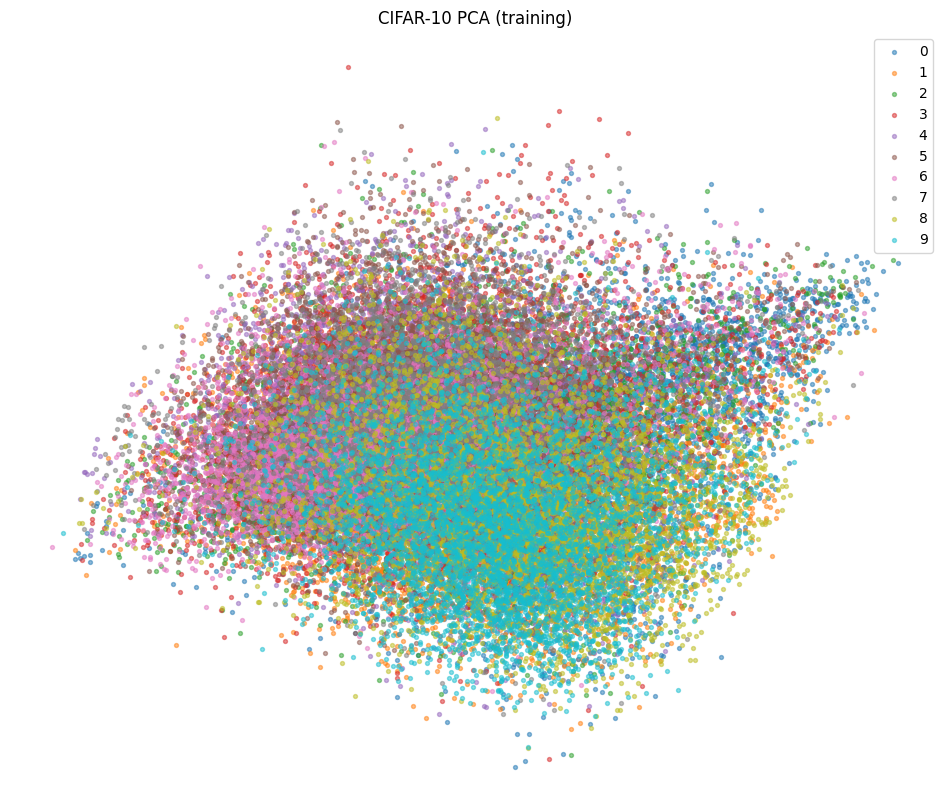

In [15]:
plot_embedding(pca_emb, y_train, 'CIFAR-10 PCA (training)')

1b

The manifold shows some structure, loose overlapping groups

1c

In [17]:
pca_1 = pca.components_[0].T
pca_2 = pca.components_[1].T

print(pca_1.shape)
print(pca_2.shape)

(3072,)
(3072,)


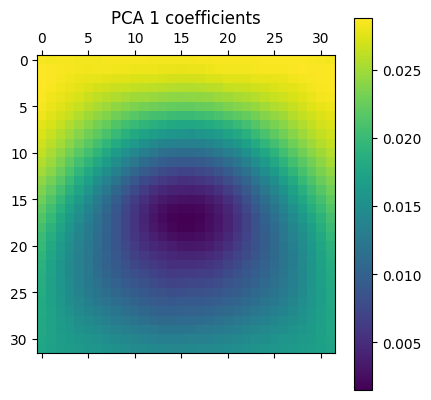

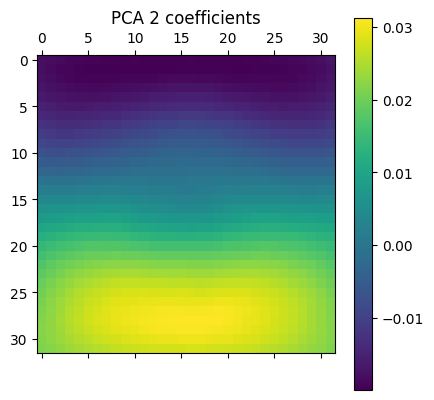

In [18]:
plt.matshow(pca_1.reshape(32,32,3).mean(axis=2))
plt.title("PCA 1 coefficients")
plt.colorbar()
plt.show()

plt.matshow(pca_2.reshape(32,32,3).mean(axis=2))
plt.title("PCA 2 coefficients")
plt.colorbar()
plt.show()

In [19]:
id1 = np.where(np.abs(pca_1) < 0.01)[0]
id2 = np.where(np.abs(pca_2) < 0.01)[0]

len(id1), len(id2), len(set(id1).intersection(set(id2)))

(707, 938, 274)

For CIFAR there are less obvious weak areas since the image is spread more broadly across the image.

1d

In CIFAR more pixels contribute meaninful information which makes prediction harder compared to MNIST, since MNIST has a lot of whitespace in the background.

2a

In [22]:
pca_full = PCA(n_components=X_train_flat.shape[1], svd_solver='full')
pca_full.fit(X_train_flat)

total_variance = np.sum(pca_full.explained_variance_)
x = 0.0
m = 0.9
i = 0

while i < pca_full.n_components_ and x < m:
    x += pca_full.explained_variance_[i] / total_variance
    i += 1

i

99

2b

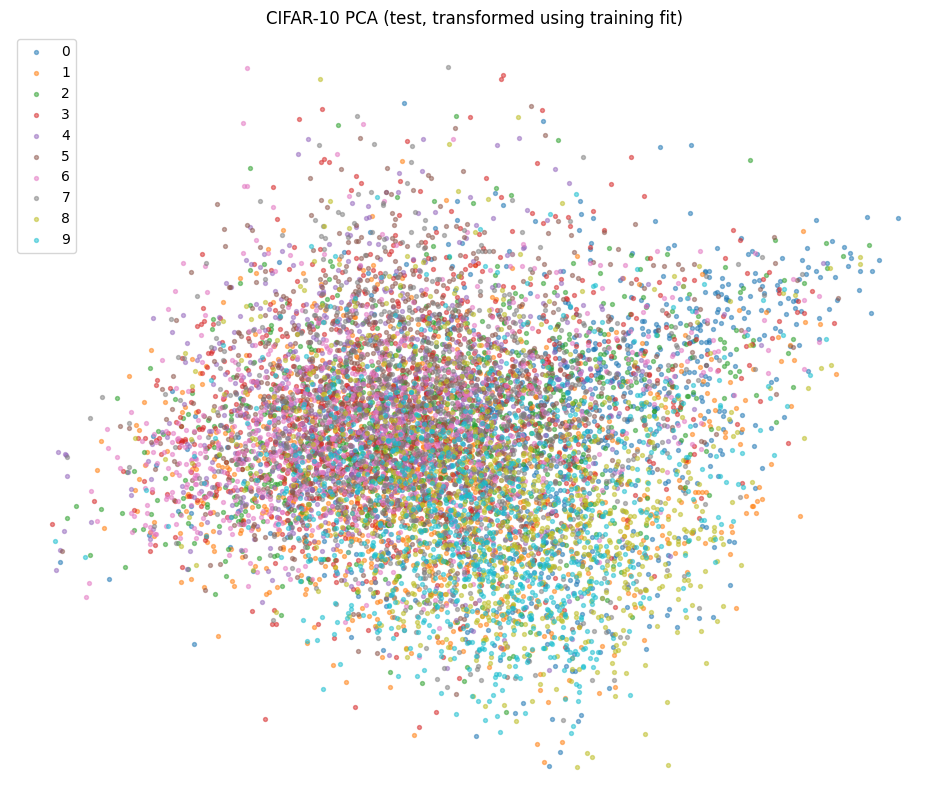

In [23]:
pca_test_emb = pca.transform(X_test_flat)
plot_embedding(pca_test_emb, y_test, 'CIFAR-10 PCA (test, transformed using training fit)')

Similar pattern, class overlap is still high

3a

In [24]:
np.random.seed(0)

labeled_idx = np.random.choice(np.arange(X_test_flat.shape[0]), size=2000, replace=False)

all_idx = np.arange(X_test_flat.shape[0])
eval_idx = np.setdiff1d(all_idx, labeled_idx)

X_labeled = X_test_flat[labeled_idx]
y_labeled = y_test[labeled_idx]

X_eval = X_test_flat[eval_idx]
y_eval = y_test[eval_idx]

y_train_missing = -1 * np.ones(y_train.shape[0], dtype=int)

X_ssl = np.vstack((X_train_flat, X_labeled))
y_ssl = np.concatenate((y_train_missing, y_labeled))

X_ssl, y_ssl = shuffle(X_ssl, y_ssl, random_state=0)

print(X_ssl.shape, y_ssl.shape)

(52000, 3072) (52000,)


3b

In [25]:
unique, counts = np.unique(y_ssl, return_counts=True)
dict(zip(unique, counts))

{-1: 50000,
 0: 176,
 1: 211,
 2: 198,
 3: 204,
 4: 207,
 5: 186,
 6: 198,
 7: 202,
 8: 205,
 9: 213}

In [26]:
print("count of -1 labels:", np.sum(y_ssl == -1))
for k in range(10):
    print("count of", k, "labels:", np.sum(y_ssl == k))

count of -1 labels: 50000
count of 0 labels: 176
count of 1 labels: 211
count of 2 labels: 198
count of 3 labels: 204
count of 4 labels: 207
count of 5 labels: 186
count of 6 labels: 198
count of 7 labels: 202
count of 8 labels: 205
count of 9 labels: 213


3c

In [27]:
pca_ssl = PCA(n_components=100, svd_solver='full')
pca_ssl.fit(X_ssl)

X_ssl_pca = pca_ssl.transform(X_ssl)
X_eval_pca = pca_ssl.transform(X_eval)

print(X_ssl_pca.shape, X_eval_pca.shape)

(52000, 100) (8000, 100)


In [28]:
lp = LabelPropagation()
lp.fit(X_ssl_pca, y_ssl)

,"kernel kernel: {'knn', 'rbf'} or callable, default='rbf'String identifier for kernel function to use or the kernel functionitself. Only 'rbf' and 'knn' strings are valid inputs. The functionpassed should take two inputs, each of shape (n_samples, n_features),and return a (n_samples, n_samples) shaped weight matrix.",'rbf'
,"gamma gamma: float, default=20Parameter for rbf kernel.",20
,"n_neighbors n_neighbors: int, default=7Parameter for knn kernel which need to be strictly positive.",7
,"max_iter max_iter: int, default=1000Change maximum number of iterations allowed.",1000
,"tol tol: float, default=1e-3Convergence tolerance: threshold to consider the system at steadystate.",0.001
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


3d

In [29]:
y_pred = lp.predict(X_eval_pca)
acc = accuracy_score(y_eval, y_pred)
acc

/Users/teddytaussig/anaconda3/envs/COM328_2/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


0.103

In [30]:
print("accuracy on the 8000 held-out test samples:", acc)

accuracy on the 8000 held-out test samples: 0.103
